Nombre: Felipe Aravena
Rut: 21.128.400-5
Fecha: 29-04-2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook

output_notebook() 

Loading BokehJS ...

In [2]:
#Ejercicio 1: Gráfico de línea - Evolución mensual de ingresos por categoría
#1.1
df = pd.read_csv('techstore_chile_2024.csv')
print("Shape:", df.shape)
print("Tipos de datos:\n", df.dtypes)
print("\nValores Nulos")
print(df.isnull().sum())

Shape: (300, 7)
Tipos de datos:
 mes                  int64
categoria              str
unidades             int64
precio_unitario    float64
ingresos           float64
nps                  int64
devueltos            int64
dtype: object

Valores Nulos
mes                0
categoria          0
unidades           0
precio_unitario    0
ingresos           0
nps                0
devueltos          0
dtype: int64


El dataset contiene 230 filas y 7 columnas. Los tipos de datos incluyen enteros (mes, unidades, nps, devueltos), flotantes (precio_unitario, ingresos) y strings (categoria). Al revisar, no se aprecian columnas con valores faltantes (nulos).

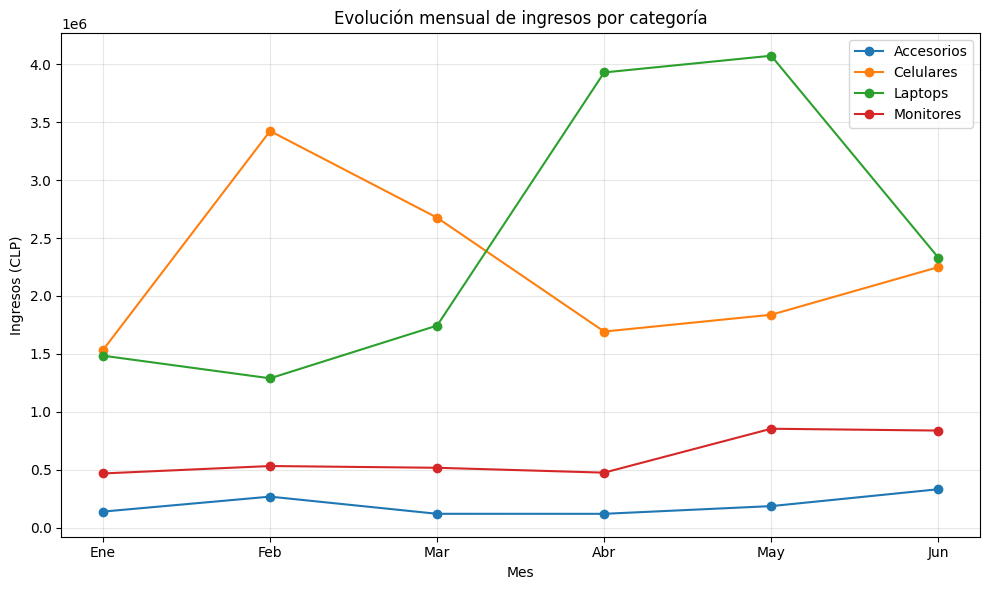

In [3]:
#1.2
fig, ax = plt.subplots(figsize=(10, 6))

# Generamos el gráfico agrupando por categoría 
for categoria in df['categoria'].unique():
    subset = df[df['categoria'] == categoria].groupby('mes')['ingresos'].sum()
    ax.plot(subset.index, subset.values, marker='o', label=categoria) 

ax.set_xticks(range(1, 7))
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun'])
ax.set_title('Evolución mensual de ingresos por categoría')
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (CLP)')
ax.legend()
ax.grid(True, alpha=0.3) 

plt.tight_layout() # Para ajustar los márgenes 
plt.show()

#1.3
¿Que categoría presenta la mayor tasa de crecimiento mensual?¿A que podria deberse?

Al observar la pendiente de las graficas se puede observar que la categoría "Celulares" presenta el mayor crecimiento, lo cual suele asociarse a factores estacionales, campañas de marketing o lanzamientos de productos.El crecimiento se identifica observando la línea con la pendiente más pronunciada en el gráfico

#1.4
¿Por qué se utiliza ax.set_xticks() junto con ax.set_xticklabels()? ¿Qué ocurre si solo usa uno de los dos?

ax.set_xticks() define las posiciones numéricas exactas en el eje, mientras que ax.set_xticklabels() asigna el texto visible a dichas posiciones. Usar solo uno puede desalinear las etiquetas o generar errores gráficos


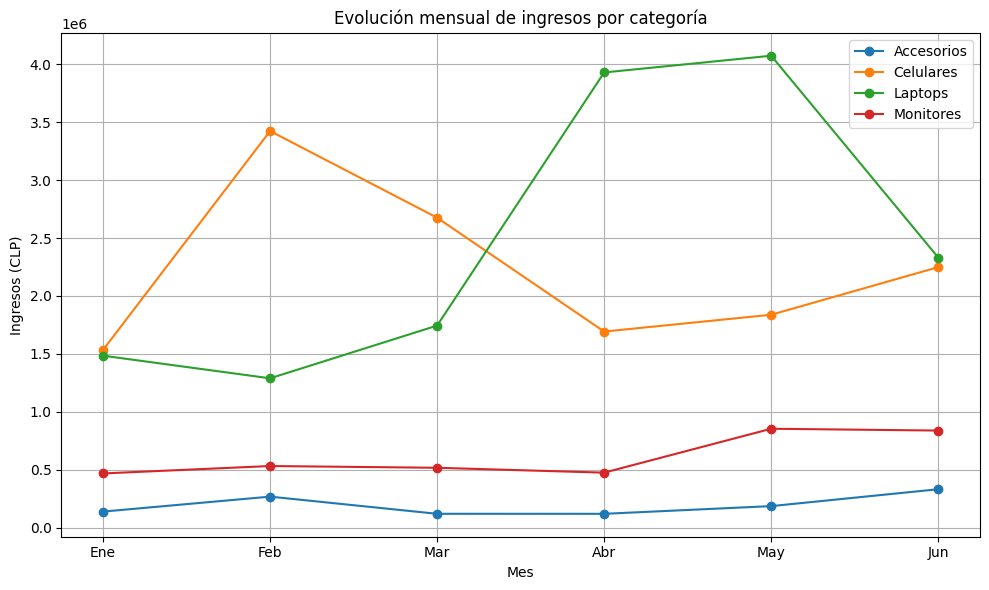

In [4]:
#1.5
fig, ax = plt.subplots(figsize=(10, 6))

# Generamos el gráfico agrupando por categoría 
for categoria in df['categoria'].unique():
    subset = df[df['categoria'] == categoria].groupby('mes')['ingresos'].sum()
    ax.plot(subset.index, subset.values, marker='o', label=categoria) 

ax.set_xticks(range(1, 7))
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun'])
ax.set_title('Evolución mensual de ingresos por categoría')
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (CLP)')
ax.legend()
ax.grid(True, alpha=1) 

plt.tight_layout() # Para ajustar los márgenes 
plt.show()

1.5¿Qué ventaja aporta el parámetro alpha en ax.grid()? Pruebe con alpha=1.0 y compare.

Mirando los dos graficos se puede observar que alpha seria quien regule la opacidad del fondo, siendo asi que con un valor mas alto la cuadricula sea mas visible, probando con otros valores se sabe que el valor puede ser establecido entre 0 y 1

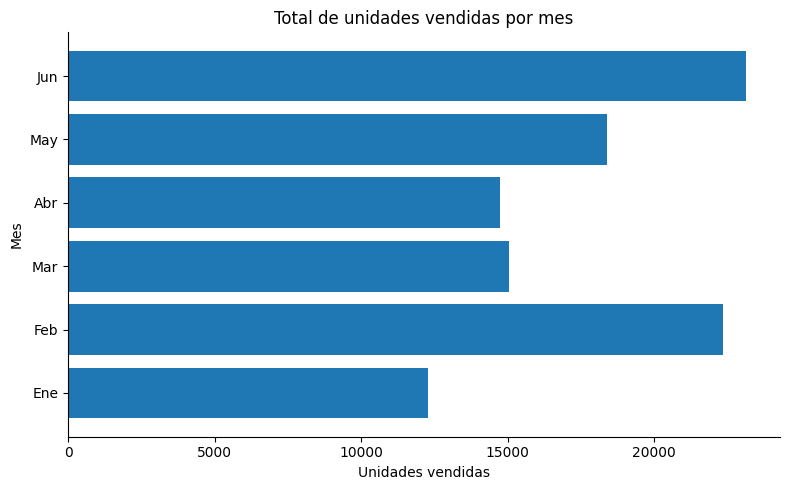

In [5]:
#Ejercicio 2: Gráfico de barras horizontal - Comparación de unidades vendidas por mes
#2.1  
# Generar subset agrupando unidades por mes
ventas_mes = df.groupby('mes')['unidades'].sum()
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']

fig, ax = plt.subplots(figsize=(8, 5))

# Gráfico de barras horizontal utilizando el color por defecto de Matplotlib
ax.barh(meses_labels, ventas_mes.values) 

ax.set_title('Total de unidades vendidas por mes')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('Mes')

# Ocultar ejes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

2.2 ¿Cuál es la diferencia entre ax.bar() y ax.barh()? ¿En qué contextos preferiría cada uno?

ax.bar() genera columnas verticales, mientras que ax.barh() genera barras horizontales. Se prefiere ax.barh() cuando las etiquetas de categoría son largas, ya que mejora significativamente la legibilidad sin tener que rotar el texto.

2.3 ¿Por qué se ocultan los ejes superior y derecho con ax.spines['top'].set_visible(False)? ¿Qué efecto visual produce?

Ocultar los bordes superior y derecho limpia el gráfico, reduciendo la "tinta no de datos". Esto produce un efecto visual más moderno y dirige la atención del espectador directamente a la longitud de las barras.

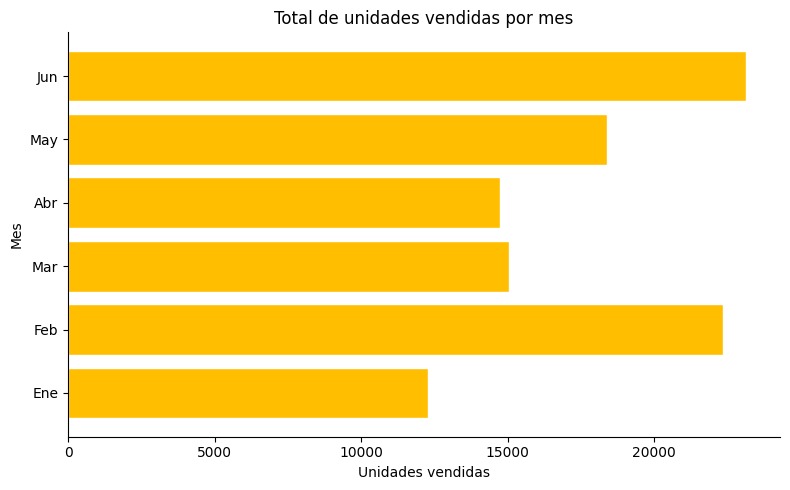

In [6]:
#2.4 Modifique el color de las barras para que los meses con más de 1.400 unidades se destaquen en color ámbar
ventas_mes = df.groupby('mes')['unidades'].sum()
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']

# Modificar color si supera las 1400 unidades 
colores = ['#FFBF00' if val > 1400 else '#F79625' for val in ventas_mes.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(meses_labels, ventas_mes.values, color=colores, edgecolor='white') # Barras horizontales 

ax.set_title('Total de unidades vendidas por mes')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('Mes')

# Ocultar ejes superior y derecho 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

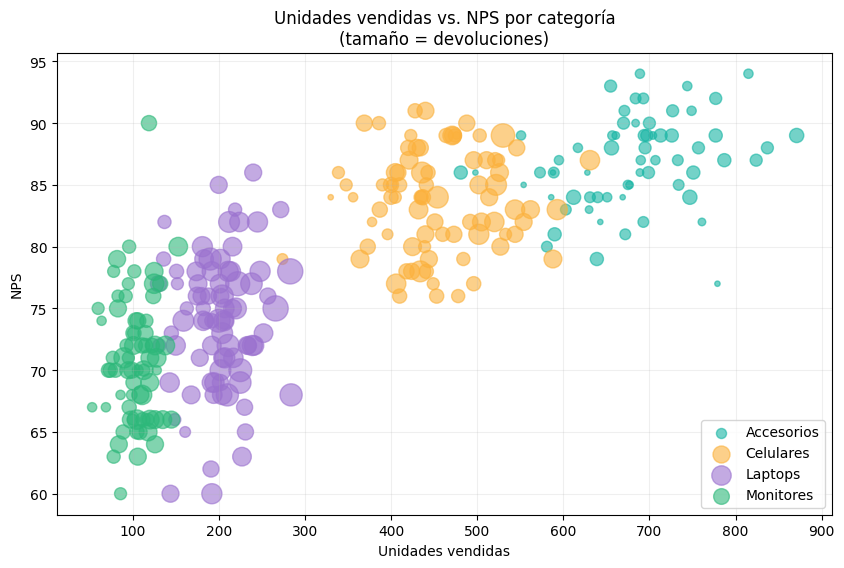

In [7]:
#Ejercicio 3: Gráfico de dispersión - Relación entre unidades vendidas y NPS
#3.1
fig, ax = plt.subplots(figsize=(10, 6))
categorias = df['categoria'].unique()
colores_cmap = ['#17B5A4','#FBB13C', '#9B72CF','#2DB87A'] # Colores de la clase 

for i, cat in enumerate(categorias):
    subset = df[df['categoria'] == cat]
    # Se incluye el tamaño s= y la transparencia alpha= 
    ax.scatter(subset['unidades'], subset['nps'], 
               s=subset['devueltos'] * 15, # Tamaño según devoluciones
               alpha=0.6, 
               label=cat, 
               color=colores_cmap[i])

ax.set_title('Unidades vendidas vs. NPS por categoría\n(tamaño = devoluciones)')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('NPS')
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

3.2 ¿Existe una relación visible entre el volumen de ventas y el NPS? Describa la tendencia observada.

Se observa una relación general positiva. Las categorías que concentran un mayor volumen de unidades vendidas también tienden a agrupar los puntajes NPS más altos. 

3.3 ¿Por qué se multiplica df['devueltos'] * 15 en el parámetro s? ¿Qué sucede con valores muy
pequeños o muy grandes?

Se multiplica por 15 para escalar visualmente el área de los marcadores. Sin esto, los valores de devoluciones (que son números pequeños) generarían puntos invisibles. Valores desproporcionadamente grandes provocarían un solapamiento masivo.

3.4 ¿Qué representa cada dimensión visual del gráfico (posición X, posición Y, color, tamaño)?

La posición X indica las unidades vendidas, la posición Y el puntaje NPS, el color diferencia la categoría del producto, y el tamaño representa la cantidad de devoluciones.  

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el archivo forzando el separador de coma
df = pd.read_csv('techstore_chile_2024.csv', sep=',')

# Mostramos las primeras 3 líneas para confirmar
display(df.head(3))

,mes,categoria,unidades,precio_unitario,ingresos,nps,devueltos
0,1,Accesorios,639,26.6,16997.4,79,6
1,1,Accesorios,603,27.4,16522.2,83,4
2,1,Accesorios,617,27.1,16720.7,88,3


In [16]:
#Ejercicio 4: Composición 2×2 — Panel analítico de ventas


4.1 ¿Qué conclusión integrada puede extraer del panel observando los cuatro gráficos en conjunto?

4.2 ¿Por qué se usa fig.suptitle() en lugar de ax.set_title() para el título global? ¿Cuál es la diferencia?


4.3¿Qué hace axes.flat en el bucle for al final? ¿Cómo simplifica el código?


In [9]:
#Ejercicio 5: Visualización interactiva con Bokeh - HoverTool sobre ingresos 
#5.1
# Preparar datos agregados 
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
ingresos_mes = df.groupby('mes').agg(ingresos=('ingresos', 'sum'), unidades=('unidades', 'sum')).reset_index()
ingresos_mes['mes_label'] = meses_labels
ingresos_mes['ingresos_fmt'] = ingresos_mes['ingresos'].map(lambda x: f'${x:,.0f} K')

# ColumnDataSource permite vincular los datos 
source = ColumnDataSource(ingresos_mes)

# Configuración del tooltip, incluyendo unidades vendidas
hover = HoverTool(tooltips=[
    ('Mes', '@mes_label'),
    ('Ingresos', '@ingresos_fmt'),
])

# Crear figura Bokeh 
p = figure(
    x_range=meses_labels, 
    title="Ingresos Totales por Mes",
    height=400,
    tools=[hover, "pan,wheel_zoom,box_zoom,reset"] # Integración de herramientas 
)

# Agregar barras 
p.vbar(
    x='mes_label',
    top='ingresos',
    source=source,
    width=0.65,
    color='#0D9488',
    line_color='#065F52',
    fill_alpha=0.85 
)

p.xgrid.grid_line_color = None
p.ygrid.grid_line_alpha = 0.3
p.yaxis.axis_label = 'Ingresos (CLP miles)'
p.xaxis.axis_label = 'Mes'
p.title.text_font_size = '13px'

show(p) # Muestra el gráfico interactivo 

5.2¿Qué ventaja aporta el ColumnDataSource frente a pasar listas directamente a p.vbar()?

ColumnDataSource es una fuente de datos estructurada y estandarizada en Bokeh. Su gran ventaja es que permite la interacción y el enlace (linking) entre múltiples gráficos, de modo que al seleccionar datos en un gráfico, la acción se refleje en otros. Además, facilita el paso de diccionarios/DataFrames a las herramientas interactivas.

5.3¿Cómo se define la cadena @mes_label en el tooltip? ¿Qué relación tiene con las claves del diccionario en ColumnDataSource?

El prefijo @ le indica al HoverTool que busque directamente una columna (o clave del diccionario) llamada mes_label dentro del ColumnDataSource. Extraerá el valor correspondiente a esa columna para la barra específica sobre la cual el usuario tiene el cursor.  


In [10]:
#5.4 Agregue una tercera fila al tooltip que muestre el total de unidades vendidas en ese mes.
# Preparar datos agregados 
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
ingresos_mes = df.groupby('mes').agg(ingresos=('ingresos', 'sum'), unidades=('unidades', 'sum')).reset_index()
ingresos_mes['mes_label'] = meses_labels
ingresos_mes['ingresos_fmt'] = ingresos_mes['ingresos'].map(lambda x: f'${x:,.0f} K')

# ColumnDataSource permite vincular los datos 
source = ColumnDataSource(ingresos_mes)

# Configuración del tooltip, incluyendo unidades vendidas
hover = HoverTool(tooltips=[
    ('Mes', '@mes_label'),
    ('Ingresos', '@ingresos_fmt'),
    ('Unidades Vendidas', '@unidades') # Tercera fila solicitada 
])

# Crear figura Bokeh 
p = figure(
    x_range=meses_labels, 
    title="Ingresos Totales por Mes",
    height=400,
    tools=[hover, "pan,wheel_zoom,box_zoom,reset"] # Integración de herramientas 
)

# Agregar barras 
p.vbar(
    x='mes_label',
    top='ingresos',
    source=source,
    width=0.65,
    color='#0D9488',
    line_color='#065F52',
    fill_alpha=0.85 
)

p.xgrid.grid_line_color = None
p.ygrid.grid_line_alpha = 0.3
p.yaxis.axis_label = 'Ingresos (CLP miles)'
p.xaxis.axis_label = 'Mes'
p.title.text_font_size = '13px'

show(p) # Muestra el gráfico interactivo 